# <font color="purple"><h3 align="center">DataFrame Basics Tutorial</h3></font>

## **Dataframe is most commonly used object in pandas. It is a table like datastructure containing rows and columns similar to excel spreadsheet**

In [1]:
import pandas as pd
weather_data = {
    'day': ['1/1/2017','1/2/2017','1/3/2017','1/4/2017','1/5/2017','1/6/2017'],
    'temperature': [32,35,28,24,32,31],
    'windspeed': [6,7,2,7,4,2],
    'event': ['Rain', 'Sunny', 'Snow','Snow','Rain', 'Sunny']
}
df = pd.DataFrame(weather_data)
df = pd.read_csv("weather_data.csv")
df

,day,temperature,windspeed,event
0,1/1/2017,32,6,Rain
1,1/2/2017,-99999,7,Sunny
2,1/3/2017,28,-99999,Snow
3,1/4/2017,24,7,Snow
4,1/5/2017,-99999,4,no event
5,1/6/2017,31,2,Sunny


In [2]:
df.shape # rows, columns = df.shape

(6, 4)

## <font color='blue'>Rows</font>

In [3]:
df.head(2) # df.head(3)

,day,temperature,windspeed,event
0,1/1/2017,32,6,Rain
1,1/2/2017,-99999,7,Sunny


In [4]:
df.tail(1) # df.tail(2)

,day,temperature,windspeed,event
5,1/6/2017,31,2,Sunny


In [5]:
df[2:3]

,day,temperature,windspeed,event
2,1/3/2017,28,-99999,Snow


## <font color='blue'>Columns</font>

In [6]:
df.columns

Index(['day', 'temperature', 'windspeed', 'event'], dtype='object')

In [7]:
df['day'].tail(3) # or df.day

3    1/4/2017
4    1/5/2017
5    1/6/2017
Name: day, dtype: object

In [8]:
df.day.head(2)

0    1/1/2017
1    1/2/2017
Name: day, dtype: object

In [9]:
#see what's the type of a dataframe column, e.g 'day'
df.day.dtype
df.temperature.dtype
df.windspeed.dtype

df.dtypes

day            object
temperature     int64
windspeed       int64
event          object
dtype: object

In [10]:
#show day and temperature of dataframe
df[[ 'day', 'temperature' ]].head(3)

,day,temperature
0,1/1/2017,32
1,1/2/2017,-99999
2,1/3/2017,28


## <font color='blue'>Operations On DataFrame</font>

In [11]:
df['temperature'].max()

32

In [12]:
df[df['temperature']>32]
df['temperature']>32

0    False
1    False
2    False
3    False
4    False
5    False
Name: temperature, dtype: bool

In [13]:
# df['day'][df['temperature'] == df.temperature.max()] # Kinda doing SQL in pandas
df.loc[df['temperature'] == df['temperature'].max(), 'day']

0    1/1/2017
Name: day, dtype: object

In [14]:
# df[df['temperature'] == df['temperature'].max()] # Kinda doing SQL in pandas
# df['temperature'] == df['temperature'].max()
df[df.temperature == df['temperature'].max()]

,day,temperature,windspeed,event
0,1/1/2017,32,6,Rain


In [15]:
#Find standard deviation of temperature
df.temperature.std()

51654.10806283142

In [16]:
df['event'].max() # But mean() won't work since data type is string
# df.event.min()
# df.event.mean()

'no event'

In [17]:
df.describe()
df.describe().head(4)
df.describe().mean()

temperature   -19569.715659
windspeed      -9475.921616
dtype: float64

**Google pandas series operations to find out list of all operations**
http://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.html

## <font color='blue'>set_index</font>

In [18]:
df.set_index('day')
# df.set_index('event')

,temperature,windspeed,event
day,,,
1/1/2017,32,6,Rain
1/2/2017,-99999,7,Sunny
1/3/2017,28,-99999,Snow
1/4/2017,24,7,Snow
1/5/2017,-99999,4,no event
1/6/2017,31,2,Sunny


In [19]:
df.set_index('day', inplace=True)
#df.set_index('temperature', inplace=True)

In [20]:
df.index

Index(['1/1/2017', '1/2/2017', '1/3/2017', '1/4/2017', '1/5/2017', '1/6/2017'], dtype='object', name='day')

In [21]:
df.loc['1/2/2017']
# df.loc['1/2/2027']

temperature    -99999
windspeed           7
event           Sunny
Name: 1/2/2017, dtype: object

In [22]:
df.reset_index(inplace=True)
df.head()

,day,temperature,windspeed,event
0,1/1/2017,32,6,Rain
1,1/2/2017,-99999,7,Sunny
2,1/3/2017,28,-99999,Snow
3,1/4/2017,24,7,Snow
4,1/5/2017,-99999,4,no event


In [23]:
df.set_index('event',inplace=True) # this is kind of building a hash map using event as a key
df

,day,temperature,windspeed
event,,,
Rain,1/1/2017,32,6
Sunny,1/2/2017,-99999,7
Snow,1/3/2017,28,-99999
Snow,1/4/2017,24,7
no event,1/5/2017,-99999,4
Sunny,1/6/2017,31,2


In [24]:
df.loc['Snow']

,day,temperature,windspeed
event,,,
Snow,1/3/2017,28,-99999
Snow,1/4/2017,24,7


# <font color="purple"><h3 align="center">Pandas Concatenate Tutorial</h3></font>

## <font color='blue'>Basic Concatenation</font>

In [25]:
import pandas as pd

#pakistani_weather = pd.DataFrame({
#    "city": ["karachi","lahore","peshawar"],
#    "temperature": [32,45,30],
#    "humidity": [80, 60, 78]
#})
#pakistani_weather

# Practice
weather = {
    "city": ["karachi","lahore","peshawar"],
    "temperature": [32,45,30],
    "humidity": [80, 60, 78]
}

pakistani_weather = pd.DataFrame(weather)
pakistani_weather

,city,temperature,humidity
0,karachi,32,80
1,lahore,45,60
2,peshawar,30,78


In [26]:
us_weather = pd.DataFrame({
    "city": ["new york","chicago","orlando"],
    "temperature": [21,14,35],
    "humidity": [68, 65, 75]
})
us_weather

,city,temperature,humidity
0,new york,21,68
1,chicago,14,65
2,orlando,35,75


In [27]:
#concatinate us and pakistani weather
concated_weather = pd.concat([pakistani_weather, us_weather])
concated_weather

,city,temperature,humidity
0,karachi,32,80
1,lahore,45,60
2,peshawar,30,78
0,new york,21,68
1,chicago,14,65
2,orlando,35,75


## <font color='blue'>Ignore Index</font>

In [28]:
df = pd.concat([pakistani_weather, us_weather], ignore_index=True)
df

,city,temperature,humidity
0,karachi,32,80
1,lahore,45,60
2,peshawar,30,78
3,new york,21,68
4,chicago,14,65
5,orlando,35,75


## <font color='blue'>Concatenation And Keys</font>

In [29]:
df = pd.concat([pakistani_weather, us_weather], keys=["pakistan", "us"])
df

city  temperature  humidity
pakistan 0   karachi           32        80
         1    lahore           45        60
         2  peshawar           30        78
us       0  new york           21        68
         1   chicago           14        65
         2   orlando           35        75

In [30]:
#show city temperate and humidity of us cities

#df.loc['us'][['temperature', 'humidity']]
df.loc['us']['temperature']
#df.loc['us'].temperature
#df.loc.us.temperature

0    21
1    14
2    35
Name: temperature, dtype: int64

In [31]:
#show information of pakistani cities (city, temperature, humidity)

df.loc['pakistan']
#df.loc['pakistan'][['city', 'temperature', 'humidity']]

,city,temperature,humidity
0,karachi,32,80
1,lahore,45,60
2,peshawar,30,78


## <font color='blue'>Concatenation Using Index</font>

In [32]:
temperature_df = pd.DataFrame({
    "city": ["karachi","lahore","peshawar"],
    "temperature": [32,45,30],
}, index=[0,1,2])
temperature_df

,city,temperature
0,karachi,32
1,lahore,45
2,peshawar,30


In [33]:
windspeed_df = pd.DataFrame({
    "city": ["lahore","karachi"],
    "windspeed": [7,12],
}, index=[1,0])
windspeed_df

,city,windspeed
1,lahore,7
0,karachi,12


In [34]:
#concatenate the temperature and windspeed of Lahore, Karachi and Peshawar

#concated_cities = pd.concat([temperature_df, windspeed_df]).join
concated_cities = pd.merge(temperature_df, windspeed_df, on='city', how='outer')

concated_cities

,city,temperature,windspeed
0,karachi,32,12.0
1,lahore,45,7.0
2,peshawar,30,NaN


## <font color='blue'>Concatenate dataframe with series</font>

In [35]:
s = pd.Series(["Humid","Dry","Rain"], name="event")
s

0    Humid
1      Dry
2     Rain
Name: event, dtype: object

In [36]:
df = pd.concat([temperature_df,s], axis=1)
df

,city,temperature,event
0,karachi,32,Humid
1,lahore,45,Dry
2,peshawar,30,Rain


## <font color="maroon"><h4 align="center">Pandas Group By</font>

In [37]:
import pandas as pd
df = pd.read_csv("weather_by_cities.csv")
df

,day,city,temperature,windspeed,event
0,1/1/2024,new york,32,6,Rain
1,1/2/2024,new york,36,7,Sunny
2,1/3/2024,new york,28,12,Snow
3,1/4/2024,new york,33,7,Sunny
4,1/1/2024,dubai,90,5,Sunny
5,1/2/2024,dubai,85,12,Fog
6,1/3/2024,dubai,87,15,Fog
7,1/4/2024,dubai,92,5,Rain
8,1/1/2024,paris,45,20,Sunny
9,1/2/2024,paris,50,13,Cloudy


### For this dataset, get following answers,
#### 1. What was the maximum temperature in each of these 3 cities?
#### 2. What was the average windspeed in each of these 3 cities?


In [47]:
g = df.groupby("city")
g

In [50]:
# maximum temperature in each of these 3 cities

df.groupby('city')['temperature'].max()
#g.temperature.max()

city
dubai       92
new york    36
paris       54
Name: temperature, dtype: int64

In [54]:
# average windspeed in each of these 3 cities

#g.windspeed.mean()
#g['windspeed'].mean()
g[['windspeed']].mean()

,windspeed
city,
dubai,9.25
new york,8.00
paris,12.75


**DataFrameGroupBy object looks something like below,**

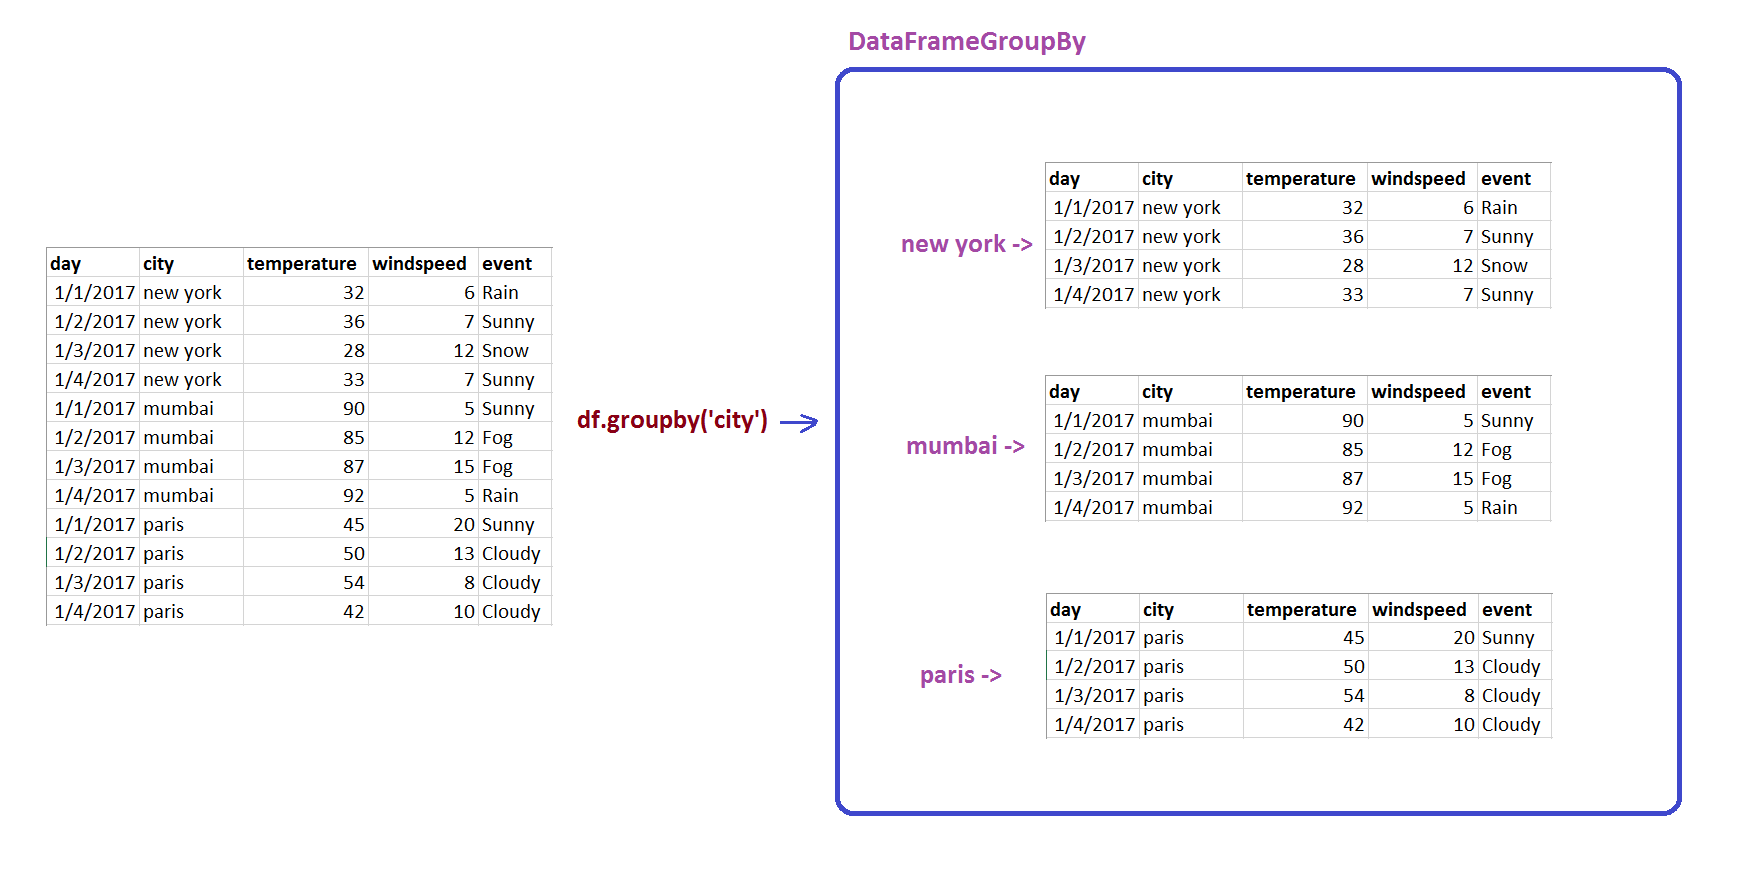

In [70]:
#for city, info in g:
#    print("city:",city)
#    print("\n")
#    print("info:",info)

for info in g:
    #print(info)
    #print('\n')
    print('city:', info[0])
    print('info:', '\n', info[1], '\n')
    #print('\n')

city: dubai
info: 
         day   city  temperature  windspeed  event
4  1/1/2024  dubai           90          5  Sunny
5  1/2/2024  dubai           85         12    Fog
6  1/3/2024  dubai           87         15    Fog
7  1/4/2024  dubai           92          5   Rain 

city: new york
info: 
         day      city  temperature  windspeed  event
0  1/1/2024  new york           32          6   Rain
1  1/2/2024  new york           36          7  Sunny
2  1/3/2024  new york           28         12   Snow
3  1/4/2024  new york           33          7  Sunny 

city: paris
info: 
          day   city  temperature  windspeed   event
8   1/1/2024  paris           45         20   Sunny
9   1/2/2024  paris           50         13  Cloudy
10  1/3/2024  paris           54          8  Cloudy
11  1/4/2024  paris           42         10  Cloudy 



**This is similar to SQL,**

> SELECT * from weather_data GROUP BY city

In [72]:
#g.get_group('paris')

g.get_group('paris')[['temperature']]

,temperature
8,45
9,50
10,54
11,42


In [41]:
g.min()

,day,temperature,windspeed,event
city,,,,
dubai,1/1/2024,85,5,Fog
new york,1/1/2024,28,6,Rain
paris,1/1/2024,42,8,Cloudy


In [77]:
#g.mean(numeric_only=True)

g[['temperature', 'windspeed']].mean()

,temperature,windspeed
city,,
dubai,88.50,9.25
new york,32.25,8.00
paris,47.75,12.75


**This method of splitting your dataset in smaller groups and then applying an operation
(such as min or max) to get aggregate result is called Split-Apply-Combine. It is illustrated in a diagram below**

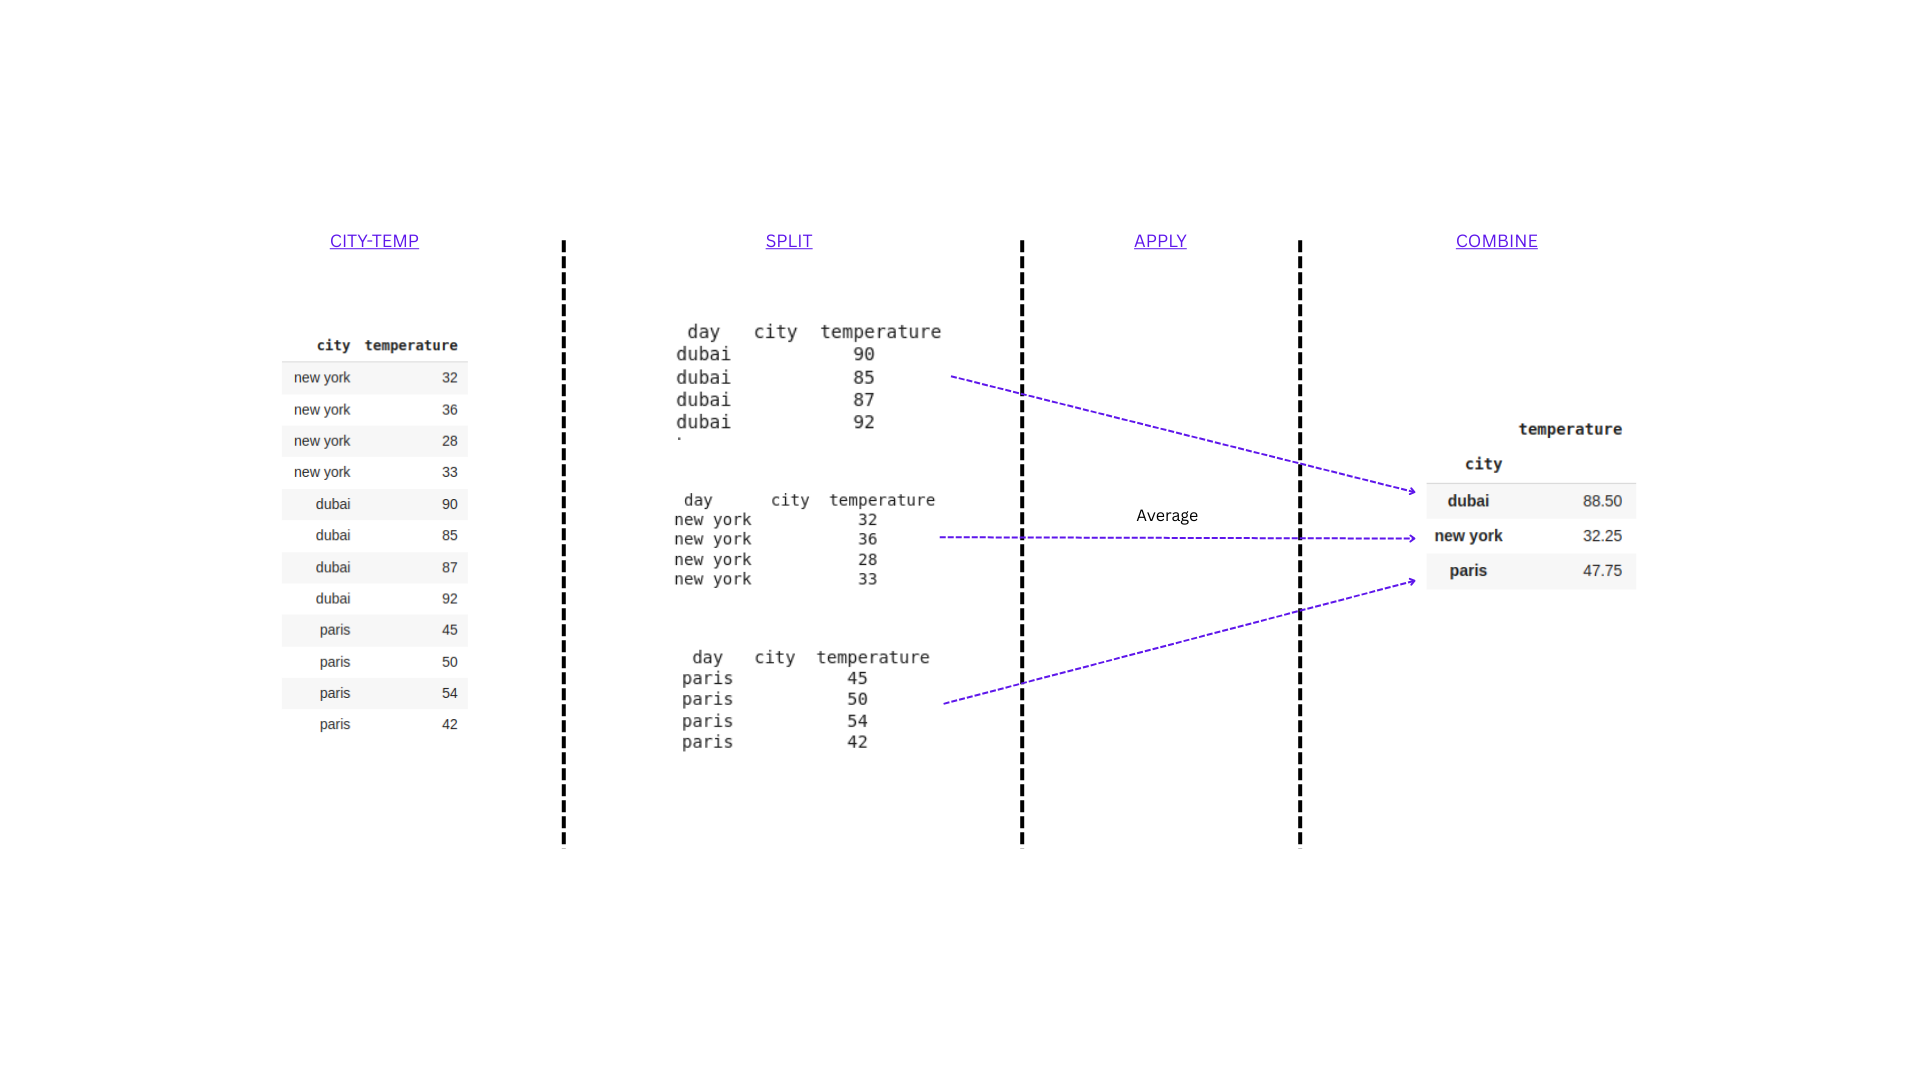

In [83]:
# show the minimum of city group  (g)

g[['temperature', 'windspeed']].min()
#g[['windspeed']].min()

,temperature,windspeed
city,,
dubai,85,5
new york,28,6
paris,42,8


In [84]:
# show statistical information of g

g.describe()

temperature                                                   \
               count   mean       std   min    25%   50%    75%   max   
city                                                                    
dubai            4.0  88.50  3.109126  85.0  86.50  88.5  90.50  92.0   
new york         4.0  32.25  3.304038  28.0  31.00  32.5  33.75  36.0   
paris            4.0  47.75  5.315073  42.0  44.25  47.5  51.00  54.0   

         windspeed                                                 
             count   mean       std  min   25%   50%    75%   max  
city                                                               
dubai          4.0   9.25  5.057997  5.0  5.00   8.5  12.75  15.0  
new york       4.0   8.00  2.708013  6.0  6.75   7.0   8.25  12.0  
paris          4.0  12.75  5.251984  8.0  9.50  11.5  14.75  20.0

In [91]:
#g.size()

g.size().to_frame(name = 'count')

,count
city,
dubai,4
new york,4
paris,4


# <font color="purple"><h3 align="center">Pandas Merge Tutorial</h3></font>

## <font color='blue'>Basic Merge Using a Dataframe Column</font>

In [93]:
import pandas as pd
df1 = pd.DataFrame({
    "city": ["new york", "chicago", "orlando"],
    "temperature": [21,14,35],
})
df1

,city,temperature
0,new york,21
1,chicago,14
2,orlando,35


In [94]:
df2 = pd.DataFrame({
    "city": ["chicago", "new york", "orlando"],
    "humidity": [65,68,75],
})
df2

,city,humidity
0,chicago,65
1,new york,68
2,orlando,75


In [95]:
#merge df1 and df2 on city

pd.merge(df1, df2)

,city,temperature,humidity
0,new york,21,68
1,chicago,14,65
2,orlando,35,75


## <font color='blue'>Type Of DataBase Joins</font>

<img src="db_joins.jpg" height="800", width="800">

In [96]:
df1 = pd.DataFrame({
    "city": ["new york","chicago","orlando", "baltimore"],
    "temperature": [21,14,35, 38],
})
df1

,city,temperature
0,new york,21
1,chicago,14
2,orlando,35
3,baltimore,38


In [97]:
df2 = pd.DataFrame({
    "city": ["chicago","new york","san diego"],
    "humidity": [65,68,71],
})
df2

,city,humidity
0,chicago,65
1,new york,68
2,san diego,71


In [99]:
df3 = pd.merge(df1, df2, on="city", how="inner")
df3

,city,temperature,humidity
0,new york,21,68
1,chicago,14,65


In [100]:
df3=pd.merge(df1,df2,on="city",how="outer")
df3

,city,temperature,humidity
0,baltimore,38.0,NaN
1,chicago,14.0,65.0
2,new york,21.0,68.0
3,orlando,35.0,NaN
4,san diego,NaN,71.0


In [101]:
df3=pd.merge(df1,df2,on="city",how="left")
df3

,city,temperature,humidity
0,new york,21,68.0
1,chicago,14,65.0
2,orlando,35,NaN
3,baltimore,38,NaN


In [104]:
df3 = pd.merge(df1, df2, on="city", how="right")
df3

,city,temperature,humidity
0,chicago,14.0,65
1,new york,21.0,68
2,san diego,NaN,71


## <font color='blue'>indicator flag</font>

In [103]:
df3 = pd.merge(df1, df2, on="city", how="outer", indicator=True)
df3

,city,temperature,humidity,_merge
0,baltimore,38.0,NaN,left_only
1,chicago,14.0,65.0,both
2,new york,21.0,68.0,both
3,orlando,35.0,NaN,left_only
4,san diego,NaN,71.0,right_only


## <font color='blue'>suffixes</font>

In [105]:
df1 = pd.DataFrame({
    "city": ["new york", "chicago", "orlando", "baltimore"],
    "temperature": [21,14,35,38],
    "humidity": [65,68,71, 75]
})
df1

,city,temperature,humidity
0,new york,21,65
1,chicago,14,68
2,orlando,35,71
3,baltimore,38,75


In [106]:
df2 = pd.DataFrame({
    "city": ["chicago", "new york", "san diego"],
    "temperature": [21,14,35],
    "humidity": [65,68,71]
})
df2

,city,temperature,humidity
0,chicago,21,65
1,new york,14,68
2,san diego,35,71


In [116]:
#df3 = pd.merge(df1, df2, on="city", how="outer", suffixes=('_left','_right'))
df3 = pd.merge(df1, df2, on="city", how="outer")
df3

,city,temperature_x,humidity_x,temperature_y,humidity_y
0,baltimore,38.0,75.0,NaN,NaN
1,chicago,14.0,68.0,21.0,65.0
2,new york,21.0,65.0,14.0,68.0
3,orlando,35.0,71.0,NaN,NaN
4,san diego,NaN,NaN,35.0,71.0


## <font color='blue'>join</font>

In [117]:
df1 = pd.DataFrame({
    "city": ["new york","chicago","orlando"],
    "temperature": [21,14,35],
})
df1.set_index('city',inplace=True)
df1

,temperature
city,
new york,21
chicago,14
orlando,35


In [118]:
df2 = pd.DataFrame({
    "city": ["chicago","new york","orlando"],
    "humidity": [65,68,75],
})
df2.set_index('city',inplace=True)
df2

,humidity
city,
chicago,65
new york,68
orlando,75


In [120]:
import pandas as pd
import numpy as np
df = pd.read_csv("weather.csv")
df

,date,city,temperature,humidity
0,5/1/2024,new york,65,56
1,5/2/2024,new york,66,58
2,5/3/2024,new york,68,60
3,5/1/2024,dubai,75,80
4,5/2/2024,dubai,78,83
5,5/3/2024,dubai,82,85
6,5/1/2024,beijing,80,26
7,5/2/2024,beijing,77,30
8,5/3/2024,beijing,79,35


In [121]:
df.pivot(index='city',columns='date')

temperature                   humidity                  
date        5/1/2024 5/2/2024 5/3/2024 5/1/2024 5/2/2024 5/3/2024
city                                                             
beijing           80       77       79       26       30       35
dubai             75       78       82       80       83       85
new york          65       66       68       56       58       60

In [122]:
df.pivot(index='city',columns='date',values="humidity")

date,5/1/2024,5/2/2024,5/3/2024
city,,,
beijing,26,30,35
dubai,80,83,85
new york,56,58,60


In [123]:
df.pivot(index='date',columns='city')

temperature                humidity               
city         beijing dubai new york  beijing dubai new york
date                                                       
5/1/2024          80    75       65       26    80       56
5/2/2024          77    78       66       30    83       58
5/3/2024          79    82       68       35    85       60

In [124]:
#show humidity of each city.

df.pivot(index = 'city', columns = 'date', values = "humidity")

date,5/1/2024,5/2/2024,5/3/2024
city,,,
beijing,26,30,35
dubai,80,83,85
new york,56,58,60


In [36]:
import pandas as pd
import numpy as np
df = pd.read_csv("weather_data.csv")
df

,day,temperature,windspeed,event
0,1/1/2017,32,6,Rain
1,1/2/2017,-99999,7,Sunny
2,1/3/2017,28,-99999,Snow
3,1/4/2017,24,7,Snow
4,1/5/2017,-99999,4,no event
5,1/6/2017,31,2,Sunny


In [37]:
#replace all the negative values with NaN

df = df.replace({-1: np.nan, -99999: np.nan})
df

,day,temperature,windspeed,event
0,1/1/2017,32.0,6.0,Rain
1,1/2/2017,NaN,7.0,Sunny
2,1/3/2017,28.0,NaN,Snow
3,1/4/2017,24.0,7.0,Snow
4,1/5/2017,NaN,4.0,no event
5,1/6/2017,31.0,2.0,Sunny


In [39]:
#Event column it of type string, you should replace 0 with

df['event'] = df['event'].replace({
    'no event': 'Sunny'
})
df

,day,temperature,windspeed,event
0,1/1/2017,32.0,6.0,Rain
1,1/2/2017,NaN,7.0,Sunny
2,1/3/2017,28.0,NaN,Snow
3,1/4/2017,24.0,7.0,Snow
4,1/5/2017,NaN,4.0,Sunny
5,1/6/2017,31.0,2.0,Sunny
